<a href="https://colab.research.google.com/github/paramita-pp/time-series-analysis/blob/main/Introduction_to_Time_Series_Analysis_(Section_4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SETUP

In [1]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Time Series Analysis/Introduction to Time Series Forecasting/bitcoin_price.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


# Time Series Index

In [4]:
# Convert "Date" to a datetime object with the right format YYYY-MM-DD or "%Y-%m-%d"
df["Date"] = pd.to_datetime(df["Date"], format = "%Y-%m-%d")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [5]:
# Set Date as index
df.set_index("Date", inplace = True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [6]:

# Select a specific day in our df
df.loc['2021-11-09']

,2021-11-09
Open,6.754973e+04
High,6.853034e+04
Low,6.638206e+04
Close,6.697183e+04
Adj Close,6.697183e+04
Volume,4.235799e+10


In [7]:
# Load the dataset
df1 = pd.read_csv("/content/drive/MyDrive/Time Series Analysis/Introduction to Time Series Forecasting/bitcoin_price.csv",
                  index_col = "Date", parse_dates = True)
df1.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [8]:
# Resample the data to a different time granularity
df.resample("W").mean()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-21,429.916998,437.718195,406.624402,416.859003,416.859003,3.138068e+07
2014-09-28,410.650718,418.668993,399.377141,407.692566,407.692566,2.668180e+07
2014-10-05,369.774288,376.721000,353.207140,361.426570,361.426570,3.952256e+07
2014-10-12,346.927429,363.308864,337.567858,355.234580,355.234580,4.873611e+07
2014-10-19,389.010284,397.790427,380.410575,390.479854,390.479854,2.241458e+07
...,...,...,...,...,...,...
2023-12-03,38038.414062,38743.479353,37766.444196,38399.994978,38399.994978,1.919430e+10
2023-12-10,43002.227121,44027.167411,42586.383929,43538.877232,43538.877232,2.692909e+10
2023-12-17,42369.368862,42969.940848,41148.103237,42020.472656,42020.472656,2.407050e+10


# Exploratory Data Analysis

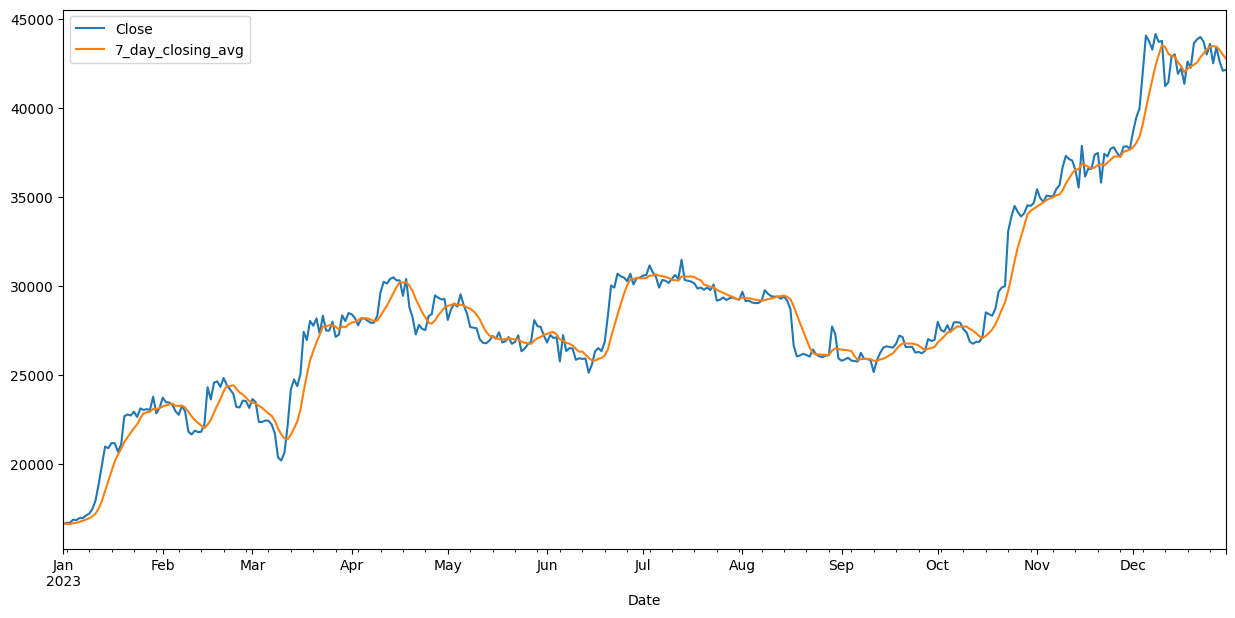

In [9]:
# Generate a 7-day rolling average for the Closing Price
df["7_day_closing_avg"] = df["Close"].rolling(window = 7).mean()

# Plot the Close Price and the 7 day rolling average
df[["Close", "7_day_closing_avg"]].loc['2023',].plot(figsize = (15, 7))
plt.show()

In [10]:
# Find the month with the highest closing average
df.resample("M").mean()["Close"].idxmax()

/tmp/ipython-input-4180989429.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample("M").mean()["Close"].idxmax()


Timestamp('2021-11-30 00:00:00')

In [11]:
# Preview the last 5 rows of the data set
df.tail()

,Open,High,Low,Close,Adj Close,Volume,7_day_closing_avg
Date,,,,,,,
2023-12-26,43599.847656,43603.175781,41676.488281,42520.402344,42520.402344,30026850982,43486.929688
2023-12-27,42518.468750,43683.160156,42167.582031,43442.855469,43442.855469,25260941032,43457.016183
2023-12-28,43468.199219,43804.781250,42318.550781,42627.855469,42627.855469,22992093014,43279.688058
2023-12-29,42614.644531,43124.324219,41424.062500,42099.402344,42099.402344,26000021055,43008.473772
2023-12-30,42091.753906,42584.125000,41556.226562,42156.902344,42156.902344,16013925945,42782.382254


In [12]:
df["daily_returns_100%"] = df["Close"].pct_change() * 100

In [13]:
# Let's check within days had more than 10% change in price
df[abs(df["daily_returns_100%"]) > 10]

,Open,High,Low,Close,Adj Close,Volume,7_day_closing_avg,daily_returns_100%
Date,,,,,,,,
2014-11-12,367.984985,429.717987,367.984985,423.561005,423.561005,45783200,365.519579,15.193570
2015-01-03,314.846008,315.149994,281.082001,281.082001,281.082001,33054400,310.171718,-10.776686
2015-01-13,267.394012,268.277008,219.906006,225.860992,225.860992,72843904,271.743853,-15.659308
2015-01-14,223.893997,223.893997,171.509995,178.102997,178.102997,97638704,255.138994,-21.144862
2015-01-15,176.897003,229.067001,176.897003,209.843994,209.843994,81773504,244.638280,17.821709
...,...,...,...,...,...,...,...,...
2022-09-09,19328.140625,21439.410156,19310.962891,21381.152344,21381.152344,48469528171,19781.450056,10.612188
2022-11-08,20600.671875,20664.607422,17603.544922,18541.271484,18541.271484,118992465607,20409.998326,-10.006132
2022-11-09,18543.761719,18590.458984,15682.692383,15880.780273,15880.780273,102905151606,19798.752093,-14.349022


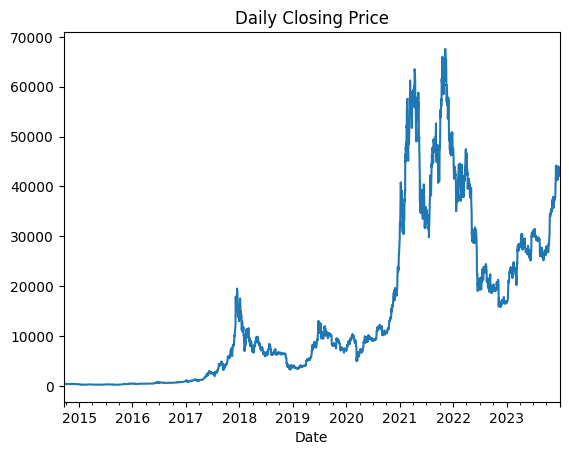

In [14]:
# Daily Closing Price Plot
df["Close"].plot(title = "Daily Closing Price")
plt.show()

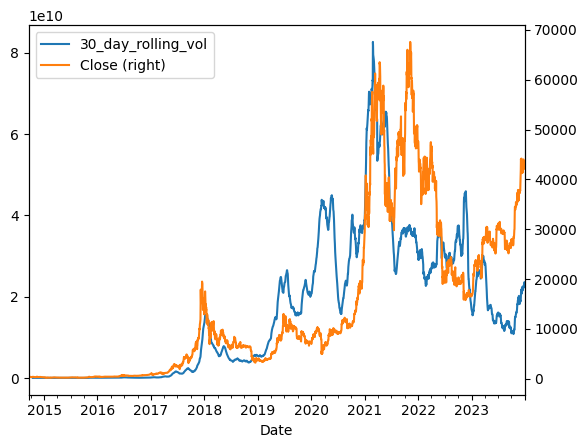

In [15]:
# Create a variable for the 30 day rolling average
df["30_day_rolling_vol"] = df["Volume"].rolling(window = 30).mean()

# Plot the Closing Price and the 30 day rolling volume
df[["30_day_rolling_vol"]].plot(legend = True)
ax = df["Close"].plot(secondary_y = True, legend = True)
plt.show()

In [16]:
# Perform correlation between closing price and 30 day rolling volume
# df["30_day_rolling_vol"].corr(df["Close"])
df[["Close", "30_day_rolling_vol"]].corr()

,Close,30_day_rolling_vol
Close,1.000000,0.750445
30_day_rolling_vol,0.750445,1.000000


This is the Pearson Correlation which often is not ideal for Time series. You might want to check Spearman Correlation.

But if we do Pearson correlation, it still 90% correct.

# Data Manipulation

In [17]:
# Identify missing values
df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
7_day_closing_avg,6
daily_returns_100%,1
30_day_rolling_vol,29


In [18]:
# Fill the missing values with the next observations
# Day 29 is missing
# Day 30 we have value
# Day 29 has now the value of day 30
# df["30_day_rolling_vol"].fillna(method = "bfill", inplace = True)
df["30_day_rolling_vol"]= df["30_day_rolling_vol"].bfill()

In [19]:
# Interpolate values
df["7_day_closing_avg"].interpolate(method = "linear", inplace = True)

/tmp/ipython-input-1271812195.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["7_day_closing_avg"].interpolate(method = "linear", inplace = True)


In [20]:
# Fetch the index
df.index.dayofweek

Index([2, 3, 4, 5, 6, 0, 1, 2, 3, 4,
       ...
       3, 4, 5, 6, 0, 1, 2, 3, 4, 5],
      dtype='int32', name='Date', length=3392)

In [21]:
# Extract time variables
df["year"] = df.index.year
df["month"] = df.index.month
df["day"] = df.index.day
df["day_of_week"] = df.index.day_of_week
df["weekday"] = df.index.day_name()
df["weekday_numeric"] = df.index.weekday

# Set a variable for weekend
# Set astype to integer to have binary
df["is_weekend"] = df["weekday_numeric"].isin([5, 6]).astype(int)

df.head()

,Open,High,Low,Close,Adj Close,Volume,7_day_closing_avg,daily_returns_100%,30_day_rolling_vol,year,month,day,day_of_week,weekday,weekday_numeric,is_weekend
Date,,,,,,,,,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,NaN,NaN,3.624856e+07,2014,9,17,2,Wednesday,2,0
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,NaN,-7.192558,3.624856e+07,2014,9,18,3,Thursday,3,0
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,NaN,-6.984265,3.624856e+07,2014,9,19,4,Friday,4,0
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,NaN,3.573492,3.624856e+07,2014,9,20,5,Saturday,5,1
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,NaN,-2.465854,3.624856e+07,2014,9,21,6,Sunday,6,1


In [22]:
# Feature Engineering - Lagged Variables
df['lag_1'] = df['Close'].shift(1)
df['lag_2'] = df['Close'].shift(2)
df.head()

,Open,High,Low,Close,Adj Close,Volume,7_day_closing_avg,daily_returns_100%,30_day_rolling_vol,year,month,day,day_of_week,weekday,weekday_numeric,is_weekend,lag_1,lag_2
Date,,,,,,,,,,,,,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800,NaN,NaN,3.624856e+07,2014,9,17,2,Wednesday,2,0,NaN,NaN
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200,NaN,-7.192558,3.624856e+07,2014,9,18,3,Thursday,3,0,457.334015,NaN
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700,NaN,-6.984265,3.624856e+07,2014,9,19,4,Friday,4,0,424.440002,457.334015
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600,NaN,3.573492,3.624856e+07,2014,9,20,5,Saturday,5,1,394.795990,424.440002
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100,NaN,-2.465854,3.624856e+07,2014,9,21,6,Sunday,6,1,408.903992,394.795990


# Seasonality

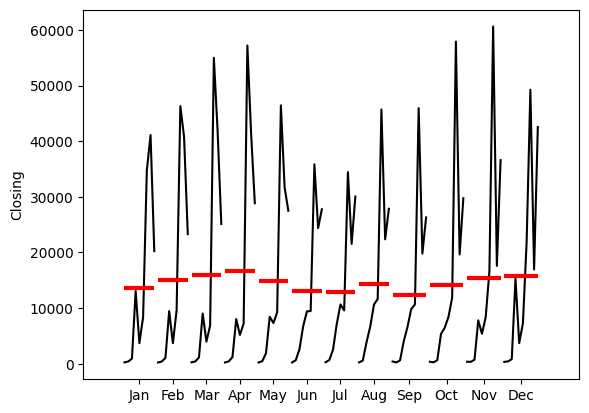

In [23]:
# Monthly seasonality
month_plot(df['Close'].resample('ME').mean(),
           ylabel = 'Closing') # ME = Month
plt.show()

/tmp/ipython-input-2209584699.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df['Close'].resample('Q').mean(),


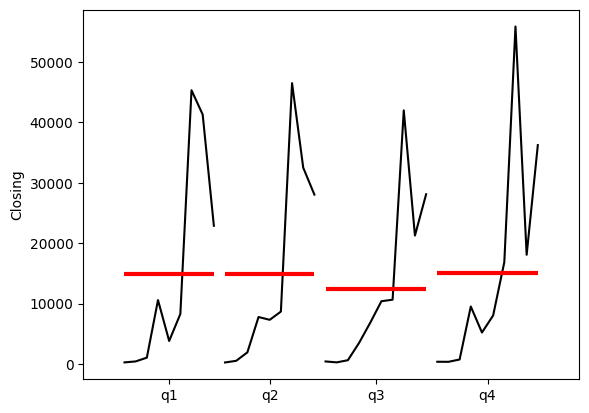

In [24]:
# Quarter plot
quarter_plot(df['Close'].resample('Q').mean(),
             ylabel = 'Closing')
plt.show()

In [25]:
# Import a second dataset
df_choco = pd.read_csv("/content/drive/MyDrive/Time Series Analysis/Introduction to Time Series Forecasting/choco_monthly_revenue.csv",
                       index_col = "Month with Year", parse_dates = True)
df_choco.head()

,revenue
Month with Year,
2018-01-01,1458
2018-02-01,1102
2018-03-01,1584
2018-04-01,1676
2018-05-01,1461


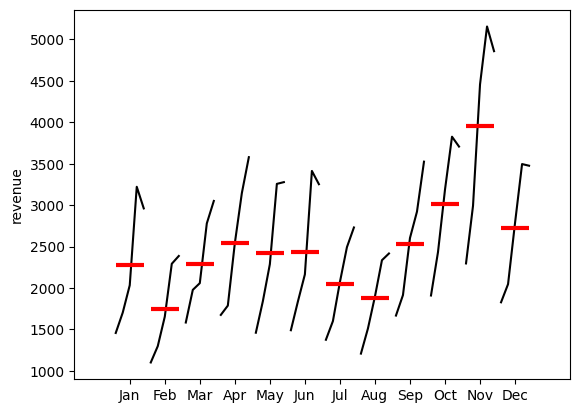

In [26]:
# Plot the month_plot for df_choco
month_plot(df_choco["revenue"], ylabel = 'revenue')
plt.show()

Seasonal_decompose only allow 1 seasonality

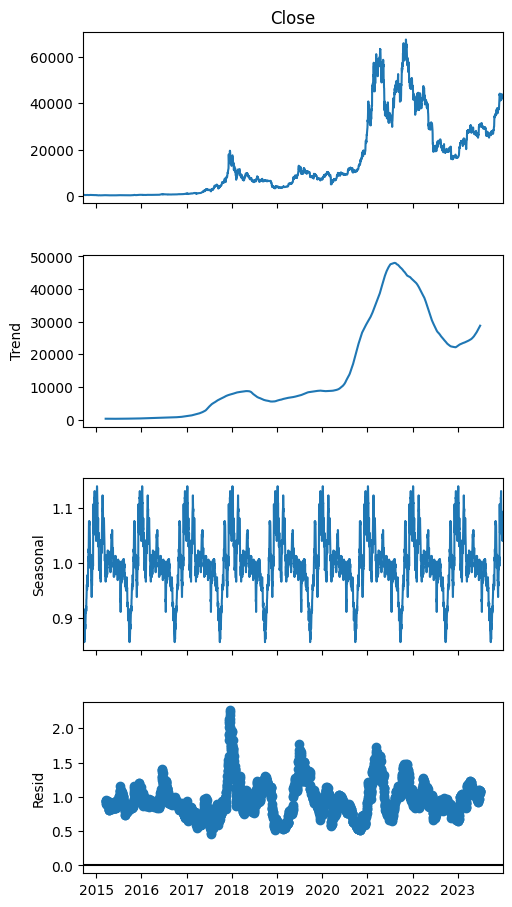

In [27]:
# seasonal decomposition for df['Adj. Close']
decomposition = seasonal_decompose(df['Close'],
                                   model = 'multiplicative',
                                   period = 365)
fig = decomposition.plot()
fig.set_size_inches(5, 10)
plt.show()

# Auto-correlation

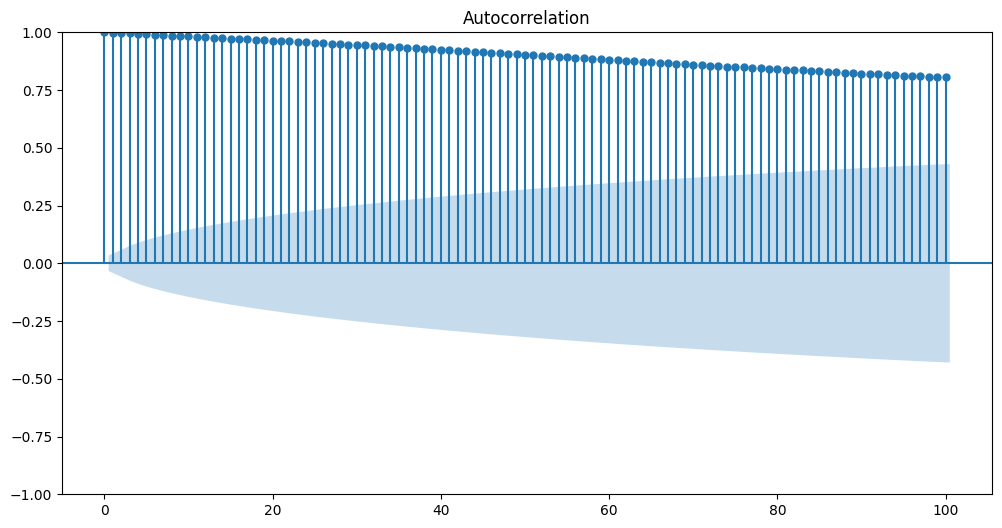

In [28]:
# Plot the ACF of the Bitcoin Adj Close
fig, ax = plt.subplots(figsize = (12, 6))
plot_acf(df['Adj Close'], lags = 100, ax = ax)
plt.show()

In [29]:
# Preview the info of df_choco
df_choco.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 60 entries, 2018-01-01 to 2022-12-01
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   revenue  60 non-null     int64
dtypes: int64(1)
memory usage: 960.0 bytes


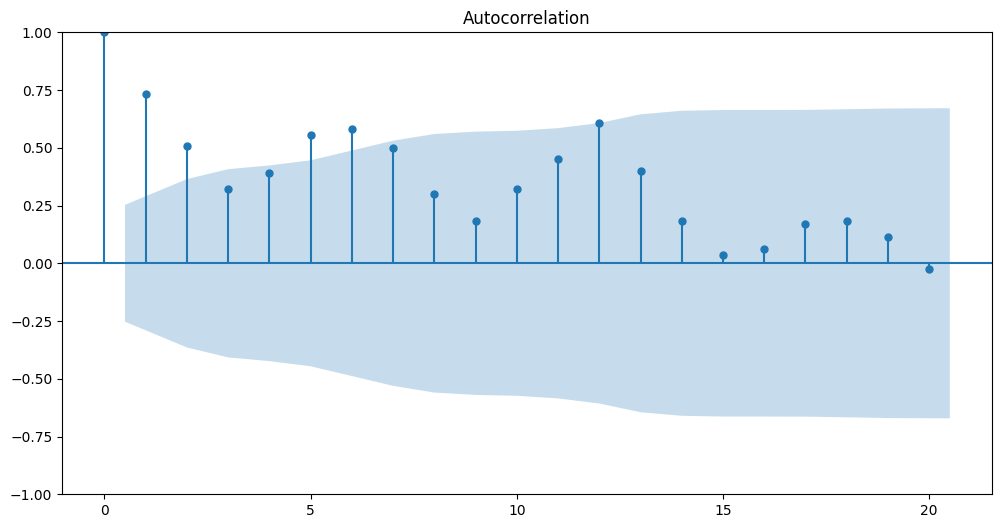

In [30]:
# Plot the ACF of the revenue kpi in df_choco
fig, ax = plt.subplots(figsize = (12, 6))
plot_acf(df_choco['revenue'], lags = 20, ax = ax)
plt.show()

# Partial Auto-Correlation

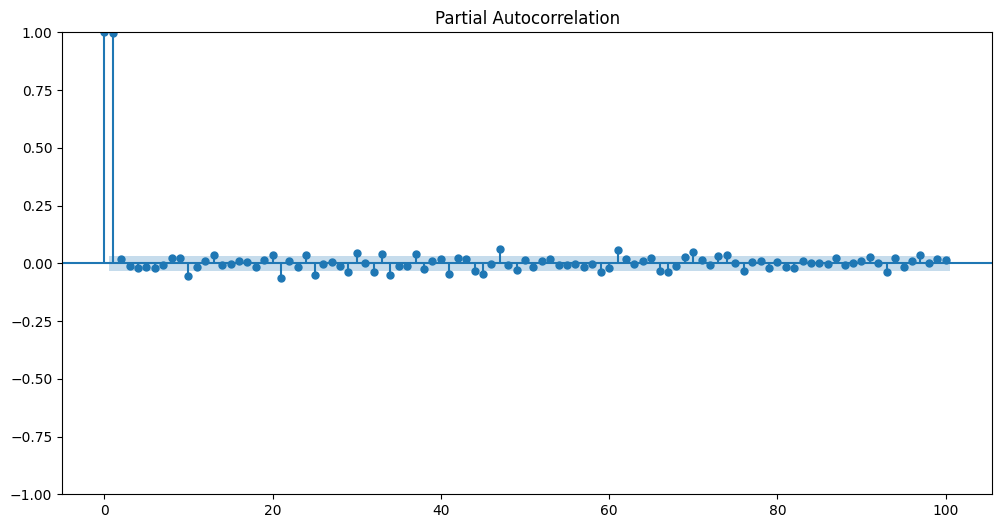

In [31]:
# PACF for bitcoin adj close
fig, ax = plt.subplots(figsize = (12, 6))
plot_pacf(df['Adj Close'], lags = 100, ax = ax)
plt.show()

The only relevant information for the price of bitcoin is what happened by day before

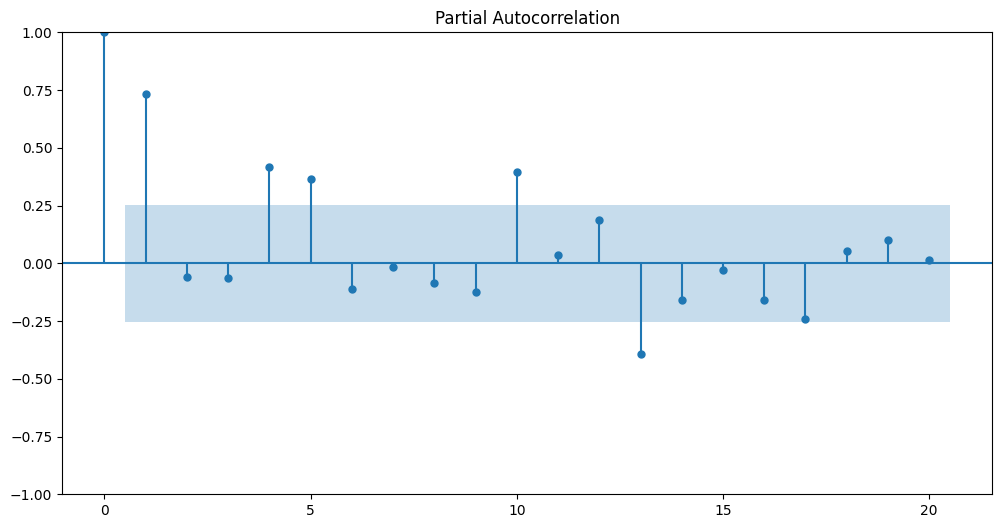

In [32]:
# PACF for the revenue in df_choco
fig, ax = plt.subplots(figsize = (12, 6))
plot_pacf(df_choco['revenue'], lags = 20, ax = ax)
plt.show()